<hr style='border-top:4px solid #1F77B4;'>

<h2><span style="color: #1F77B4; font-size: 35px">Chapitre 2</span></h2>
<h1><span style="color: #1F77B4; font-size: 50px">Préparation et prétraitement des données</span></h1>

Ce carnet reprend, dans l'ordre du chapitre, l'ensemble des extraits de code présentés dans le texte : nettoyage et typage, visualisation et traitement des données manquantes, détection des valeurs aberrantes, mise à l'échelle, détection des doublons, encodage, discrétisation, puis visualisation des distributions et des corrélations. Les cellules doivent être exécutées séquentiellement, car certaines réutilisent des variables ou des résultats définis en amont.

**Bibliothèques requises** : `numpy`, `pandas` (≥ 3), `matplotlib`, `seaborn`, `scipy` et `scikit-learn`.  
**Données externes** : les jeux de données `titanic`, `tips` et `anscombe` sont chargés avec `seaborn` ; une connexion Internet peut être nécessaire lors de leur premier chargement.  
**Exécution** : les versions utilisées sont affichées par la cellule de configuration.

<hr style='border-top:4px solid #1F77B4;'>

In [1]:
# Configuration générale : bibliothèques, versions et affichage
import sys
from importlib.metadata import version as package_version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PAQUETS = ('numpy', 'pandas', 'matplotlib', 'seaborn', 'scipy', 'scikit-learn')

print(f"{'python':<18} {sys.version.split()[0]}")
for paquet in PAQUETS:
    print(f"{paquet:<18} {package_version(paquet)}")

plt.rcParams.update({
    'mathtext.fontset': 'cm',
    'text.usetex': False,
})

# Couleurs du livre (palette viridis)
VIOLET, SARCELLE, VERT = '#482878', '#21918c', '#5ec962'
BLEU    = '#3b528b'    # nuages de données / éléments neutres
MAGENTA = '#bf00bf'    # courbes de modèle
BORD = {VIOLET: '#2e1a4d', SARCELLE: '#14615d', VERT: '#3a7d3f', BLEU: '#2c3e6b'}
ZONE = {VIOLET: '#d5cbe4', SARCELLE: '#c4e3e1', VERT: '#def2e0'}

python             3.12.13
numpy              2.5.1
pandas             3.0.3
matplotlib         3.11.0
seaborn            0.13.2
scipy              1.18.0
scikit-learn       1.9.0


In [2]:
# Fonction utilitaire de sauvegarde des figures (PDF)
import os

def save_figure(fig, path):
    directory = os.path.dirname(path)
    if directory:
        os.makedirs(directory, exist_ok=True)
    fig.savefig(f"{path}.pdf", format="pdf", bbox_inches='tight')

<hr style='border-top:4px solid #1F77B4;'>

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 2.1 : Nettoyage et typage des variables du jeu de données <i>Titanic</i></h3>

In [3]:
import seaborn as sns
from IPython.display import display

# Chargement des données
df = sns.load_dataset("titanic")
df = df[['survived', 'pclass', 'sex', 'age', 'fare', 'embarked']]

# 1. Inspection des types
print("Types avant nettoyage :")
display(df.dtypes.rename("Type").to_frame())

# 2. Conversion des types inappropriés
df['survived'] = df['survived'].astype('category')
df['pclass']   = pd.Categorical(df['pclass'],
    categories=[1, 2, 3], ordered=True)

# 3. Normalisation des chaînes de caractères
df['sex']      = df['sex'].str.strip().str.lower()
df['embarked'] = df['embarked'].str.strip().str.upper()

# 4. Vérification après nettoyage
print("\nTypes après nettoyage :")
display(df.dtypes.rename("Type").to_frame())

print("\nRépartition des passagers selon le sexe et le port d'embarquement :")
display(pd.crosstab(df['sex'], df['embarked'], margins=True, margins_name="Total"))

Types avant nettoyage :


,Type
survived,int64
pclass,int64
sex,str
age,float64
fare,float64
embarked,str



Types après nettoyage :


,Type
survived,category
pclass,category
sex,str
age,float64
fare,float64
embarked,str



Répartition des passagers selon le sexe et le port d'embarquement :


embarked,C,Q,S,Total
sex,,,,
female,73,36,203,312
male,95,41,441,577
Total,168,77,644,889


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 2.2 : Visualisation des valeurs manquantes du jeu de données <i>Titanic</i> complet</h3>

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Chargement du jeu de données complet (15 variables)
df_complet = sns.load_dataset("titanic")

# Taux de valeurs manquantes par variable (en %)
taux = (df_complet.isnull().mean() * 100).sort_values(ascending=False)
taux_manquants = taux[taux > 0]

# --- Affichage ---
L = 62
print("=" * L)
print(f"{'Variable':<12}"
      + "".join(f"{nom:>12}" for nom in taux_manquants.index))
print("-" * L)
print(f"{'Taux (%)':<12}"
      + "".join(f"{valeur:>12.1f}" for valeur in taux_manquants))
print("=" * L)

Variable            deck         age    embarked embark_town
--------------------------------------------------------------
Taux (%)            77.2        19.9         0.2         0.2


<h3><span style="font-size: 30px">&#127924;</span> Figure : Matrice de nullité et taux de valeurs manquantes (<i>Titanic</i> complet)</h3>

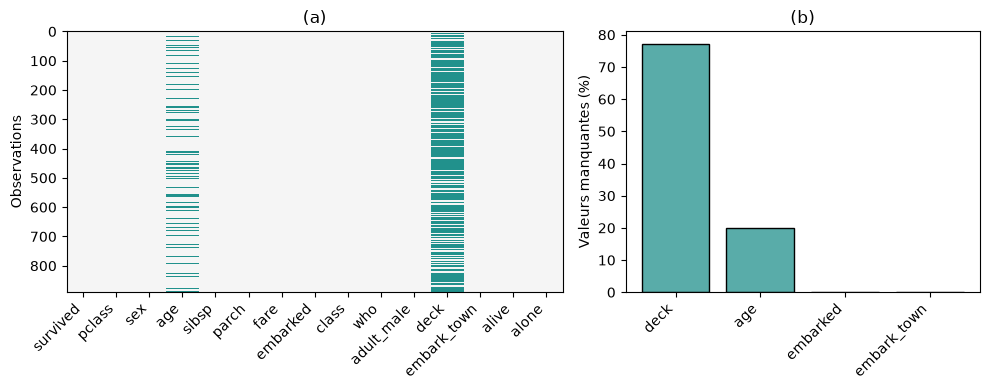

In [5]:
# Palette binaire : fond clair, manquantes en turquoise viridis
cmap_nullite = ListedColormap(['#f5f5f5', '#21918c'])

# (a) matrice de nullité, (b) taux de valeurs manquantes par variable
fig, axes = plt.subplots(1, 2, figsize=(10, 4),
    gridspec_kw={'width_ratios': [1.4, 1]})

# (a) Matrice de nullité : chaque cellule turquoise est une valeur manquante
axes[0].imshow(df_complet.isnull(), aspect='auto', cmap=cmap_nullite, interpolation='nearest')
axes[0].set_xticks(range(df_complet.shape[1]))
axes[0].set_xticklabels(df_complet.columns, rotation=45, ha='right')
axes[0].set_ylabel('Observations')
axes[0].set_title('(a)')

# (b) Taux de valeurs manquantes (variables touchées seulement)
taux_pos = taux[taux > 0]
axes[1].bar(taux_pos.index, taux_pos.values, color=plt.get_cmap('viridis')(0.5, alpha=0.75), edgecolor='black')
axes[1].set_ylabel('Valeurs manquantes (%)')
axes[1].set_title('(b)')
axes[1].tick_params(axis='x', rotation=45)
plt.setp(axes[1].get_xticklabels(), ha='right')

plt.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap2_Manquantes")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 2.3 : Importation des bibliothèques et chargement des données <i>Titanic</i></h3>

In [6]:
import seaborn as sns

# Charger le jeu de données Titanic
df = sns.load_dataset("titanic")

# Conserver seulement les colonnes d'intérêt
df = df[['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'embarked']]

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 2.4 : Suppression des données manquantes</h3>

In [7]:
# Identification des colonnes contenant des valeurs manquantes
missing_values = df.isnull().sum()
columns_with_missing_values = missing_values[missing_values > 0]

# Suppression des lignes comportant au moins une valeur manquante
df_dropped = df.dropna()
n_supprimees = len(df) - len(df_dropped)

# --- Affichage ---
L = 56
print("=" * L)
print("Valeurs manquantes")
print("-" * L)
print(f"{'Variable':<22}"
      + "".join(f"{nom:>15}" for nom in columns_with_missing_values.index))
print(f"{'Nombre':<22}"
      + "".join(f"{n:>15d}" for n in columns_with_missing_values))
print("=" * L)
print(f"{'Dimensions avant':<28}: {str(df.shape):>12}")
print(f"{'Dimensions après':<28}: {str(df_dropped.shape):>12}")
print(f"{'Lignes supprimées':<28}: {n_supprimees:>12}")
print("=" * L)

Valeurs manquantes
--------------------------------------------------------
Variable                          age       embarked
Nombre                            177              2
Dimensions avant            :     (891, 7)
Dimensions après            :     (712, 7)
Lignes supprimées           :          179


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 2.5 : Imputation des données manquantes par des statistiques simples</h3>

In [8]:
import pandas as pd
from sklearn.impute import SimpleImputer

# Copie du DataFrame pour imputation statistique
df_stat = df.copy()

# 1. Imputation de 'age' par la moyenne
mean_imputer = SimpleImputer(strategy='mean')
df_stat['age'] = mean_imputer.fit_transform(df_stat[['age']]).ravel()
age_stat = df_stat['age']

# 2. Imputation de 'embarked' par la valeur la plus fréquente (mode)
mode_imputer = SimpleImputer(strategy='most_frequent')
df_stat['embarked'] = mode_imputer.fit_transform(df_stat[['embarked']]).ravel()
embarked_stat = df_stat['embarked']

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 2.6 : Imputation des données manquantes par les $k$ plus proches voisins</h3>

In [9]:
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OrdinalEncoder

# Définir un KNN imputer avec 5 voisins
knn_imputer = KNNImputer(n_neighbors=5)

# 1. Imputation KNN pour 'age' (variable numérique)
features_num = ['age', 'fare', 'pclass', 'sibsp', 'parch']
df_knn_num = df[features_num].copy()
df_knn_imputed_num = pd.DataFrame(knn_imputer.fit_transform(df_knn_num),
                                  columns=features_num, index=df.index)
age_knn = df_knn_imputed_num['age']

# 2. Imputation KNN pour 'embarked' (variable catégorielle)
features_cat = ['embarked', 'fare', 'pclass', 'sibsp', 'parch']
df_knn_cat = df[features_cat].copy()

# Encodage -> imputation -> décodage
encoder = OrdinalEncoder()
df_knn_cat['embarked'] = encoder.fit_transform(df_knn_cat[['embarked']]).ravel()
df_knn_imputed_cat = pd.DataFrame(
    knn_imputer.fit_transform(df_knn_cat),
    columns=features_cat,
    index=df.index)

# Arrondi des codes imputés avant le décodage
codes_arrondis = np.round(
    df_knn_imputed_cat[['embarked']].values).copy()
df_knn_imputed_cat['embarked'] = encoder.inverse_transform(codes_arrondis).ravel()
embarked_knn = df_knn_imputed_cat['embarked']

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 2.7 : Imputation des données manquantes par régression linéaire</h3>

In [10]:
from sklearn.linear_model import LinearRegression

# Sélection des variables pertinentes pour prédire l'âge
df_reg = df[['age', 'fare', 'pclass', 'sibsp', 'parch']].copy()

# Jeu d'entraînement : individus avec un âge connu
df_train = df_reg.dropna(subset=['age'])

# Jeu de prédiction : individus avec un âge manquant
df_pred = df_reg[df_reg['age'].isnull()]

# Séparation des variables explicatives et de la variable cible
X_train = df_train.drop('age', axis=1)
y_train = df_train['age']
X_pred  = df_pred.drop('age', axis=1)

# Entraînement et prédiction
model = LinearRegression()
model.fit(X_train, y_train)
predicted_ages = model.predict(X_pred)

# Imputation des valeurs manquantes par les âges prédits
df_reg.loc[df_reg['age'].isnull(), 'age'] = predicted_ages
age_reg = df_reg['age']

<h3><span style="font-size: 30px">&#127924;</span> Figure : Comparaison des distributions de la variable <i>age</i> après imputation</h3>

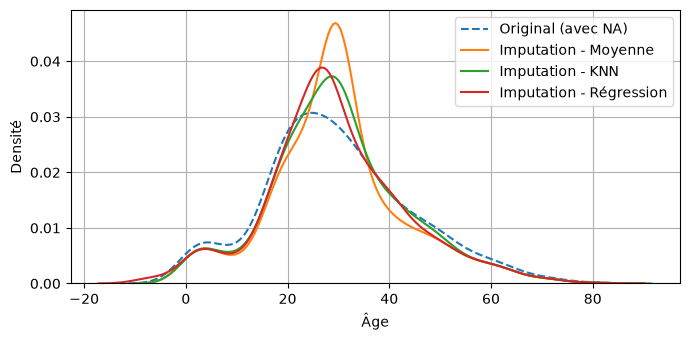

In [11]:
import matplotlib.pyplot as plt

# Distribution originale (avec valeurs manquantes)
age_original = df['age']

fig = plt.figure(figsize=(7, 3.5))
sns.kdeplot(age_original, label="Original (avec NA)", linestyle="--")
sns.kdeplot(age_stat, label="Imputation - Moyenne")
sns.kdeplot(age_knn, label="Imputation - KNN")
sns.kdeplot(age_reg, label="Imputation - Régression")
plt.xlabel("Âge")
plt.ylabel("Densité")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap2_Imputation")

plt.show()

<h3><span style="font-size: 30px">&#127924;</span> Figure : Intervalles d'une distribution normale centrée réduite ($\pm 1\sigma$, $\pm 2\sigma$, $\pm 3\sigma$)</h3>

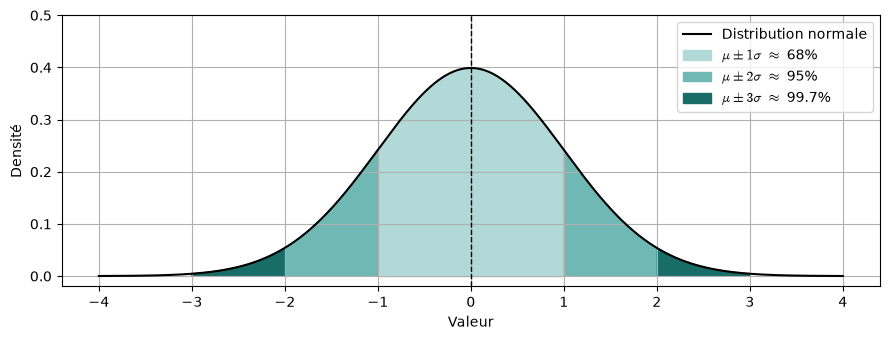

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from matplotlib.colors import to_rgb

# Paramètres de la distribution
mu = 0
sigma = 1

# Générer les données
x = np.linspace(-4, 4, 1000)
y = norm.pdf(x, mu, sigma)

# Couleur principale
base_color = np.array(to_rgb("#21918C"))

# Variantes claire, moyenne et foncée
color_1 = base_color + (1 - base_color) * 0.65
color_2 = base_color + (1 - base_color) * 0.35
color_3 = base_color * 0.75

# Tracer la courbe
fig = plt.figure(figsize=(9, 3.5))
plt.plot(x, y, color='black', label='Distribution normale')

# Zone mu +/- 1 sigma
plt.fill_between(x, y, where=(x > mu - sigma) & (x < mu + sigma),
                 color=color_1, label=r'$\mu \pm 1\sigma~\approx$ 68%')

# Zone mu +/- 2 sigma (hors 1 sigma)
plt.fill_between(x, y, where=(x > mu - 2*sigma) & (x < mu + 2*sigma) & ~((x > mu - sigma) & (x < mu + sigma)),
                 color=color_2, label=r'$\mu \pm 2\sigma~\approx$ 95%')

# Zone mu +/- 3 sigma (hors 2 sigma)
plt.fill_between(x, y, where=(x > mu - 3*sigma) & (x < mu + 3*sigma) & ~((x > mu - 2*sigma) & (x < mu + 2*sigma)),
                 color=color_3, label=r'$\mu \pm 3\sigma~\approx$ 99.7%')

# Ligne verticale sur la moyenne
plt.axvline(mu, color='black', linestyle='--', linewidth=1)

# Finitions du graphe
plt.ylim(-0.02, 0.5)
plt.xlabel("Valeur")
plt.ylabel("Densité")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap2_Normale")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 2.8 : Détection des valeurs aberrantes basée sur le score-z</h3>

In [13]:
import numpy as np
from scipy import stats

# Suppression des valeurs manquantes de la variable age
df_age = df[['age']].dropna()

# Copie du DataFrame pour ne pas écraser les données originales
df_zscore = df_age.copy()

# Détection basée sur le score-z, seuil eta_z = 3
eta_z = 3
df_zscore['z_score'] = stats.zscore(df_zscore['age'])

# Identification et stockage des valeurs aberrantes
outliers_z = df_zscore[np.abs(df_zscore['z_score']) > eta_z]

# --- Affichage ---
L = 40
print("=" * L)
print(f"Valeurs aberrantes : score-z (eta_z = {eta_z})")
print("=" * L)
print(f"{'Indice':>6}{'Âge':>14}{'Score-z':>14}")
print("-" * L)

for indice, ligne in outliers_z.iterrows():
    print(f"{indice:>6}{ligne['age']:>14g}"
          f"{ligne['z_score']:>14.2f}")

print("=" * L)

Valeurs aberrantes : score-z (eta_z = 3)
Indice           Âge       Score-z
----------------------------------------
   630            80          3.47
   851            74          3.05


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 2.9 : Détection des valeurs aberrantes basée sur l'intervalle interquartile</h3>

In [14]:
# Suppression des valeurs manquantes pour l'âge
df_age = df[["age"]].dropna()

# Paramètre de l'IQR
eta_iqr = 1.5

# Calcul des quartiles et de l'IQR
Q1 = df_age["age"].quantile(0.25)
Q3 = df_age["age"].quantile(0.75)
IQR = Q3 - Q1

# Définition des bornes
lower_bound = Q1 - eta_iqr * IQR
upper_bound = Q3 + eta_iqr * IQR

# Détection des valeurs aberrantes
outliers_iqr = df_age[
    (df_age["age"] < lower_bound)
    | (df_age["age"] > upper_bound)
]

# Préparation de l'affichage horizontal
indices = "  ".join(f"{i:>5}" for i in outliers_iqr.index)
ages = "  ".join(f"{age:>5g}" for age in outliers_iqr["age"])

# --- Affichage ---
L = 82
print("=" * L)
print("Détection des valeurs aberrantes  : IQR")
print("=" * L)
print(f"Quartile Q1                       :  {Q1:5.2f}")
print(f"Quartile Q3                       :  {Q3:5.2f}")
print(f"IQR (Q3 - Q1)                     :  {IQR:5.2f}")
print(f"Borne inférieure (Q1 - eta*IQR)   : {lower_bound:6.2f}")
print(f"Borne supérieure (Q3 + eta*IQR)   : {upper_bound:6.2f}")
print(f"Valeurs aberrantes détectées      : {len(outliers_iqr):3d}")
print("-" * L)
print(f"{'Indice':<7}{indices}")
print(f"{'Âge':<7}{ages}")
print("=" * L)

Détection des valeurs aberrantes  : IQR
Quartile Q1                       :  20.12
Quartile Q3                       :  38.00
IQR (Q3 - Q1)                     :  17.88
Borne inférieure (Q1 - eta*IQR)   :  -6.69
Borne supérieure (Q3 + eta*IQR)   :  64.81
Valeurs aberrantes détectées      :  11
----------------------------------------------------------------------------------
Indice    33     54     96    116    280    456    493    630    672    745    851
Âge       66     65     71   70.5     65     65     71     80     70     70     74


<h3><span style="font-size: 30px">&#127924;</span> Figure : Distribution univariée de <i>age</i> (boîte) et relation <i>age</i>–<i>fare</i> (nuage de points)</h3>

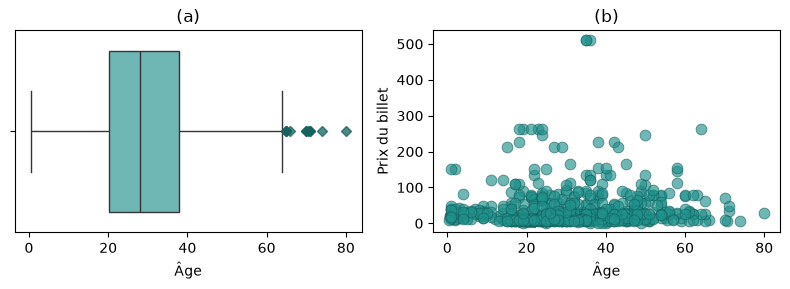

In [15]:
from matplotlib.colors import to_rgba

# Préparation des données
df_age = df[['age']].dropna()
df_scatter = df[['age', 'fare']].dropna()

# Création de la figure
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# (a) Boxplot pour détecter visuellement les valeurs aberrantes
sns.boxplot(x=df_age['age'], color=to_rgba(SARCELLE, 0.65), saturation=1, ax=axes[0],
            flierprops={"marker": "D", "markerfacecolor": BORD[SARCELLE],
                        "markeredgecolor": BORD[SARCELLE], "markersize": 5, "alpha": 0.75})
axes[0].set_title("(a)")
axes[0].set_xlabel("Âge")

# (b) Nuage de points Âge vs Prix du billet
sns.scatterplot(data=df_scatter, x='age', y='fare',
                color=SARCELLE, edgecolor=BORD[SARCELLE],
                s=60, alpha=0.65, ax=axes[1])
axes[1].set_title("(b)")
axes[1].set_xlabel("Âge")
axes[1].set_ylabel("Prix du billet")

plt.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap2_Aberrantes")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 2.10 : Mise à l'échelle de la variable <i>age</i></h3>

In [16]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Sélection de la variable 'age' et suppression des valeurs manquantes
age_data = df['age'].dropna().values.reshape(-1, 1)

# Initialisation des transformateurs
scaler_standard = StandardScaler()
scaler_minmax   = MinMaxScaler()
scaler_robust   = RobustScaler()

# Standardisation
age_standardized    = scaler_standard.fit_transform(age_data)
age_standardized_df = pd.DataFrame(age_standardized,
                                   columns=['Age_Standardized'])

# Normalisation min-max sur l'intervalle [0, 1] par défaut
# Pour normaliser sur [-1, 1] :
# scaler_minmax = MinMaxScaler(feature_range=(-1, 1))
age_normalized    = scaler_minmax.fit_transform(age_data)
age_normalized_df = pd.DataFrame(age_normalized,
                                 columns=['Age_Normalized'])

# Mise à l'échelle robuste
age_robust_scaled    = scaler_robust.fit_transform(age_data)
age_robust_scaled_df = pd.DataFrame(age_robust_scaled,
                                    columns=['Age_RobustScaled'])

<h3><span style="font-size: 30px">&#127924;</span> Figure : Distributions de <i>age</i> avant et après les trois mises à l'échelle</h3>

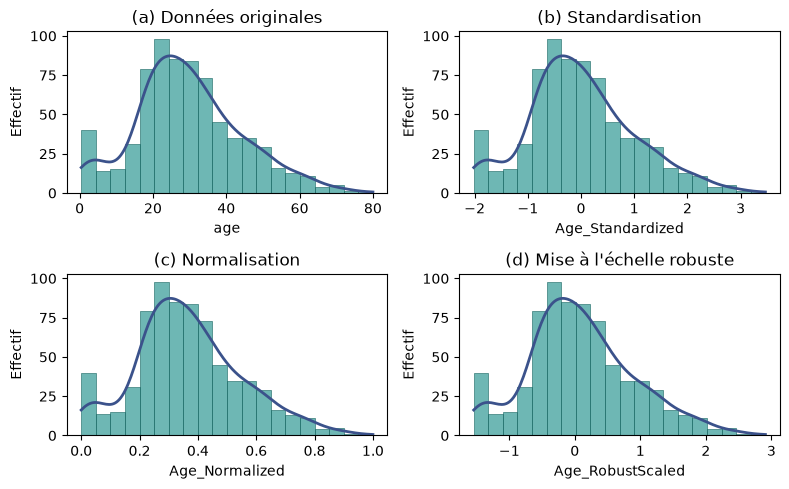

In [17]:
# Visualisation des distributions
fig, axes = plt.subplots(2, 2, figsize=(8, 5))

donnees = [
    (df['age'].dropna(),                              '(a) Données originales'),
    (age_standardized_df['Age_Standardized'],         '(b) Standardisation'),
    (age_normalized_df['Age_Normalized'],             '(c) Normalisation'),
    (age_robust_scaled_df['Age_RobustScaled'],        "(d) Mise à l'échelle robuste"),
]

for ax, (serie, titre) in zip(axes.flat, donnees):
    sns.histplot(serie, kde=True, color=SARCELLE, alpha=0.65,
                 edgecolor=BORD[SARCELLE], linewidth=0.4, ax=ax)

    # recoloration de la courbe KDE
    for ligne in ax.lines:
        ligne.set_color(BLEU)
        ligne.set_linewidth(2)

    ax.set_title(titre)
    ax.set_ylabel('Effectif')

plt.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap2_Echelle")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 2.11 : Transformation logarithmique et transformation de Yeo-Johnson de la variable <i>fare</i></h3>

In [18]:
import numpy as np
from sklearn.preprocessing import PowerTransformer

# Variable fortement asymétrique : le tarif du billet
fare = df['fare'].dropna()

# Transformation logarithmique log(1 + x), la variable comportant des zéros
fare_log = np.log1p(fare)

# Transformation de Yeo-Johnson (résultat standardisé par défaut)
pt = PowerTransformer(method='yeo-johnson')
fare_yj = pt.fit_transform(fare.values.reshape(-1, 1)).ravel()

# Coefficients d'asymétrie avant et après transformation
print(f"Asymétrie de fare           : {fare.skew():.2f}")
print(f"Asymétrie après log(1 + x)  : {fare_log.skew():.2f}")
print(f"Asymétrie après Yeo-Johnson : {pd.Series(fare_yj).skew():.2f}")

Asymétrie de fare           : 4.79
Asymétrie après log(1 + x)  : 0.39
Asymétrie après Yeo-Johnson : -0.04


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 2.12 : Détection et suppression des doublons</h3>

In [19]:
# Nombre de lignes avant traitement
n_initial = len(df)

# Détection des doublons
duplicates   = df.duplicated()
n_duplicates = duplicates.sum()

# Suppression des doublons (conservation de la première occurrence)
df_no_duplicates = df.drop_duplicates()
n_final = len(df_no_duplicates)

# Affichage des résultats
print("=" * 44)
print("Traitement des doublons")
print("=" * 44)
print(f"Nombre de lignes initial              : {n_initial}")
print(f"Nombre de lignes dupliquées détectées : {n_duplicates}")
print(f"Nombre de lignes après suppression    : {n_final}")
print("=" * 44)

Traitement des doublons
Nombre de lignes initial              : 891
Nombre de lignes dupliquées détectées : 131
Nombre de lignes après suppression    : 760


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 2.13 : Encodage de la variable <i>embarked</i></h3>

In [20]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

# Nettoyage de la variable 'embarked'
df = df[df['embarked'].isin(['C', 'Q', 'S'])].copy()

# Encodage ordinal (ordre arbitraire : C < Q < S)
ordinal_enc = OrdinalEncoder(categories=[['C', 'Q', 'S']])
df['embarked_ordinal'] = ordinal_enc.fit_transform(df[['embarked']])

# Encodage entier (codes de catégories)
df['embarked_int'] = df['embarked'].astype('category').cat.codes

# Nombre minimal de bits pour l'encodage binaire
max_bits = int(df['embarked_int'].max()).bit_length()

# Encodage binaire
binary_df = df['embarked_int'].apply(
    lambda x: pd.Series(list(map(int, format(x, f'0{max_bits}b')))))
binary_df.columns = [f'embarked_bin_{i}' for i in range(max_bits)]

# Fusion des encodages (pour illustration)
df = pd.concat([df, binary_df], axis=1)

# Affichage des résultats
L = 74
print("=" * L)
print("Encodage de la variable 'embarked'")
print("=" * L)
cols = ['embarked', 'embarked_ordinal', 'embarked_int',
        'embarked_bin_0', 'embarked_bin_1']
print(df[cols].head().to_string())

Encodage de la variable 'embarked'
  embarked  embarked_ordinal  embarked_int  embarked_bin_0  embarked_bin_1
0        S               2.0             2               1               0
1        C               0.0             0               0               0
2        S               2.0             2               1               0
3        S               2.0             2               1               0
4        S               2.0             2               1               0


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 2.14 : Encodage disjonctif (one-hot) de la variable <i>embarked</i></h3>

In [21]:
# Encodage disjonctif (one-hot) avec pandas
onehot_df = pd.get_dummies(df['embarked'],
                           prefix='embarked', dtype=int)
df = pd.concat([df, onehot_df], axis=1)

# Affichage des résultats
print(df[['embarked', 'embarked_C', 'embarked_Q', 'embarked_S']].head().to_string())

  embarked  embarked_C  embarked_Q  embarked_S
0        S           0           0           1
1        C           1           0           0
2        S           0           0           1
3        S           0           0           1
4        S           0           0           1


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 2.15 : Discrétisation de la variable <i>age</i> en quatre classes (cut et qcut)</h3>

In [22]:
# Variable age sans valeurs manquantes
age = df["age"].dropna()

# Discrétisation uniforme : 4 intervalles de largeur égale
age_cut = pd.cut(age, bins=4)
effectifs_cut = age_cut.value_counts().sort_index()

# Discrétisation par quantiles : 4 classes d'effectifs proches
age_qcut = pd.qcut(age, q=4)
effectifs_qcut = age_qcut.value_counts().sort_index()

# --- Affichage ---
L = 70
print("=" * L)
print("Comparaison des méthodes de discrétisation")
print("=" * L)
print(f"{'Classe':<8}"
      f"{'Uniforme (cut)':<18}{'Effectif':>8}"
      f"{'':10}"
      f"{'Quantiles (qcut)':<18}{'Effectif':>8}")
print("-" * L)

for i, ((intervalle_cut, n_cut),
        (intervalle_qcut, n_qcut)) in enumerate(
            zip(effectifs_cut.items(), effectifs_qcut.items()), start=1
        ):
    print(f"{i:<8}"
          f"{str(intervalle_cut):<18}{n_cut:>8}"
          f"{'':10}"
          f"{str(intervalle_qcut):<18}{n_qcut:>8}")

print("=" * L)

Comparaison des méthodes de discrétisation
Classe  Uniforme (cut)    Effectif          Quantiles (qcut)  Effectif
----------------------------------------------------------------------
1       (0.34, 20.315]         179          (0.419, 20.0]          179
2       (20.315, 40.21]        384          (20.0, 28.0]           183
3       (40.21, 60.105]        128          (28.0, 38.0]           174
4       (60.105, 80.0]          21          (38.0, 80.0]           176


<h3><span style="font-size: 30px">&#127924;</span> Figure : Bornes des deux découpages superposées à l'histogramme de <i>age</i></h3>

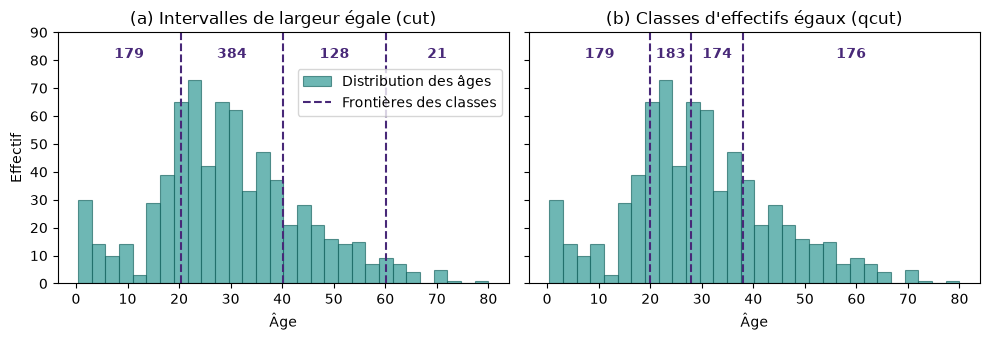

In [23]:
# Bornes des deux découpages (retbins=True renvoie les frontières)
_, edges_cut  = pd.cut(age, bins=4, retbins=True)
_, edges_qcut = pd.qcut(age, q=4, retbins=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)

for ax, edges, titre in [(axes[0], edges_cut, "(a) Intervalles de largeur égale (cut)"),
                         (axes[1], edges_qcut, "(b) Classes d'effectifs égaux (qcut)")]:
    # Distribution des âges
    ax.hist(age, bins=30, color=SARCELLE, edgecolor=BORD[SARCELLE],
            linewidth=0.8, alpha=0.65, label="Distribution des âges")

    # Frontières des classes (une seule entrée de légende)
    for i, e in enumerate(edges[1:-1]):
        ax.axvline(e, color=VIOLET, linestyle='--', linewidth=1.5,
                   label="Frontières des classes" if i == 0 else None)

    # Effectif de chaque classe, inscrit en haut du panneau
    compte = pd.cut(age, bins=edges, include_lowest=True).value_counts(sort=False).values
    for i in range(len(compte)):
        centre = (edges[i] + edges[i + 1]) / 2
        ax.text(centre, 0.94, str(compte[i]), transform=ax.get_xaxis_transform(),
                ha='center', va='top', fontsize=10, color=VIOLET,
                fontweight='bold')

    ax.set_title(titre)
    ax.set_xlabel("Âge")
    ax.set_ylim(0, 90)

axes[0].set_ylabel("Effectif")

# Légende descendue pour ne pas masquer les effectifs
axes[0].legend(loc='upper right', bbox_to_anchor=(1.0, 0.88))

plt.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap2_Discretisation")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 2.16 : Graphique en barres de <i>pclass</i> selon le statut de survie</h3>

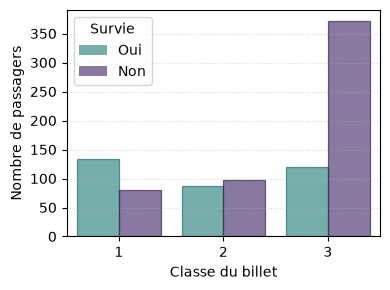

In [24]:
df_bar = df.copy()
df_bar['survived'] = df_bar['survived'].map({0: 'Non', 1: 'Oui'})
df_bar['pclass']   = df_bar['pclass'].astype(int)

fig, ax = plt.subplots(figsize=(4, 3))
sns.countplot(x='pclass', hue='survived', data=df_bar,
              palette=[SARCELLE, VIOLET], alpha=0.65, ax=ax)

# Bordure de chaque barre assortie à sa couleur de remplissage
bords = {VIOLET: BORD[VIOLET], SARCELLE: BORD[SARCELLE]}
for conteneur, coul in zip(ax.containers, [SARCELLE, VIOLET]):
    for barre in conteneur:
        barre.set_edgecolor(bords[coul])
        barre.set_linewidth(0.9)

ax.set_xlabel('Classe du billet')
ax.set_ylabel('Nombre de passagers')
ax.legend(title='Survie')
ax.grid(True, axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()

save_figure(fig, "Figures/Fig-Chap2_BarChart")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 2.17 : Diagramme en boîte des montants des factures (<i>tips</i>)</h3>

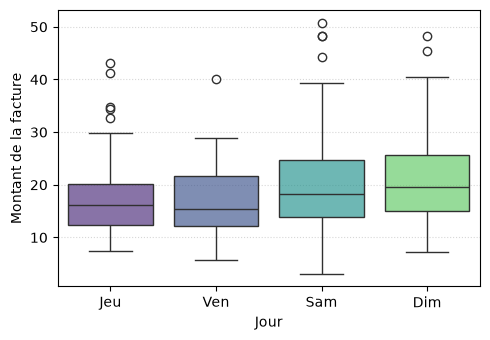

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba

# Chargement du jeu de données
tips = sns.load_dataset('tips')

# Traduction des jours en français
tips['day'] = tips['day'].cat.rename_categories(
    {'Thur': 'Jeu', 'Fri': 'Ven', 'Sat': 'Sam', 'Sun': 'Dim'})

palette_transp = [to_rgba(c, 0.65) for c in [VIOLET, BLEU, SARCELLE, VERT]]

# Diagramme en boîte par jour
fig, ax = plt.subplots(figsize=(5, 3.5))
sns.boxplot(x='day', y='total_bill', data=tips, dodge=False,
            hue='day', legend=False, ax=ax,
            palette=palette_transp, saturation=1)
ax.set_xlabel('Jour')
ax.set_ylabel('Montant de la facture')
ax.grid(True, axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap2_BoxplotTips")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 2.18 : Nombre de bins selon les règles de Sturges et de Freedman-Diaconis</h3>

In [26]:
import numpy as np

# Extraction de la variable d'intérêt
data = tips['total_bill']

# Règle de Sturges
n_bins_sturges = int(np.ceil(np.log2(len(data)) + 1))

# Règle de Freedman-Diaconis
IQR = np.percentile(data, 75) - np.percentile(data, 25)
bin_width = 2 * IQR / len(data)**(1/3)
n_bins_fd = int(np.ceil((data.max() - data.min()) / bin_width))

print(f"Nombre de bins (Sturges)           : {n_bins_sturges}")
print(f"Nombre de bins (Freedman-Diaconis) : {n_bins_fd}")

Nombre de bins (Sturges)           : 9
Nombre de bins (Freedman-Diaconis) : 14


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 2.19 : Histogrammes avec calcul automatique du nombre de bins</h3>

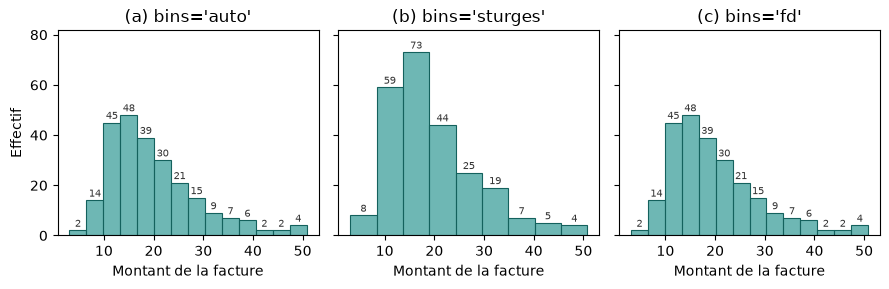

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3), sharey=True)

for ax, regle, titre in [(axes[0], 'auto',    "(a) bins='auto'"),
                         (axes[1], 'sturges', "(b) bins='sturges'"),
                         (axes[2], 'fd',      "(c) bins='fd'")]:
    sns.histplot(tips['total_bill'], bins=regle, kde=False, ax=ax,
                 color=SARCELLE, alpha=0.65,
                 edgecolor=BORD[SARCELLE], linewidth=0.8)

    # Effectif au-dessus de chaque barre (rien pour les barres vides)
    barres = ax.containers[0]
    ax.bar_label(barres,
                 labels=[f"{int(h)}" if h > 0 else '' for h in barres.datavalues],
                 fontsize=7, padding=1, color='0.2')

    ax.set_title(titre)
    ax.set_xlabel('Montant de la facture')

# Marge en haut pour que les étiquettes des plus hautes barres ne soient pas coupées
axes[0].margins(y=0.12)      # sharey : s'applique aux trois panneaux

axes[0].set_ylabel('Effectif')
axes[1].set_ylabel('')
axes[2].set_ylabel('')

plt.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap2_Histogrammes")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 2.20 : Diagramme de densité de <i>age</i> selon le statut de survie</h3>

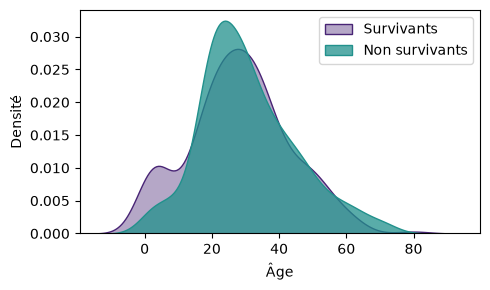

In [28]:
# Conversion temporaire de 'survived' en entier pour le filtre
df_kde = df.copy()
df_kde['survived'] = df_kde['survived'].astype(int)

fig = plt.figure(figsize=(5, 3))
sns.kdeplot(data=df_kde[df_kde['survived'] == 1]['age'].dropna(),
            label='Survivants', fill=True, alpha=0.4,
            color=plt.get_cmap('viridis')(0.1))
sns.kdeplot(data=df_kde[df_kde['survived'] == 0]['age'].dropna(),
            label='Non survivants', fill=True, alpha=0.75,
            color=plt.get_cmap('viridis')(0.5))

plt.xlabel('Âge')
plt.ylabel('Densité')
plt.legend()
plt.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap2_KDE")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 2.21 : Diagramme quantile-quantile de <i>total_bill</i> par rapport à la loi normale</h3>

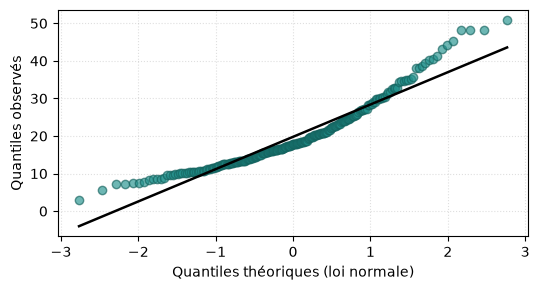

In [29]:
from scipy import stats

# Quantiles observés vs quantiles théoriques normaux
fig, ax = plt.subplots(figsize=(5.5, 3))
stats.probplot(tips['total_bill'], dist="norm", plot=ax)

# Recolorer les points et la droite de référence
points, droite = ax.get_lines()
points.set_color(SARCELLE)
points.set_markeredgecolor(BORD[SARCELLE])
# points.set_markersize(4)
points.set_alpha(0.65)
droite.set_color('black')
droite.set_linewidth(1.8)

ax.grid(True, axis='both', linestyle=':', alpha=0.4)
ax.set_title('')  # supprime le titre anglais ajouté par probplot
ax.set_xlabel('Quantiles théoriques (loi normale)')
ax.set_ylabel('Quantiles observés')
plt.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap2_QQplot")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 2.22 : Graphique en violon de <i>age</i> selon la classe et le statut de survie</h3>

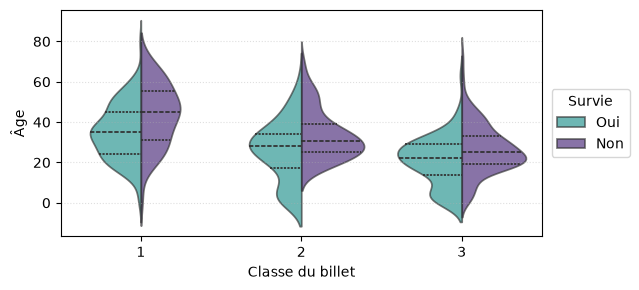

In [30]:
df_vln = df.copy()

# Remplacement des valeurs numériques par des libellés
df_vln["survived"] = df_vln["survived"].map({0: "Non", 1: "Oui"})

# Conversion de la classe du billet en entier
df_vln['pclass']   = df_vln['pclass'].astype(int)

fig, ax = plt.subplots(figsize=(6.5, 3))
sns.violinplot(x='pclass', y='age', hue='survived', alpha=0.65,
               data=df_vln, split=True, inner='quartile', saturation=1,
               palette={"Non": VIOLET, "Oui": SARCELLE}, ax=ax)
ax.set_xlabel('Classe du billet')
ax.set_ylabel('Âge')

# légende à l'extérieur, centrée verticalement à droite
ax.legend(title='Survie', loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)

ax.grid(True, axis='y', linestyle=':', alpha=0.4)
plt.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap2_ViolinPlot")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 2.23 : Diagramme de dispersion entre <i>total_bill</i> et <i>tip</i></h3>

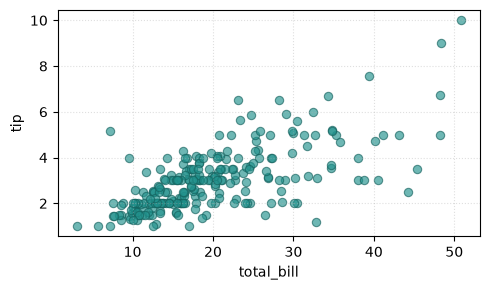

In [31]:
fig, ax = plt.subplots(figsize=(5, 3))

sns.scatterplot(x='total_bill', y='tip', data=tips,
                color=SARCELLE, edgecolor=BORD[SARCELLE], linewidth=0.8,
                alpha=0.65, ax=ax)
ax.set_xlabel('total_bill')
ax.set_ylabel('tip')
ax.grid(True, axis='both', linestyle=':', alpha=0.4)
plt.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap2_Scatter")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 2.24 : Graphique à bulles du jeu de données <i>tips</i></h3>

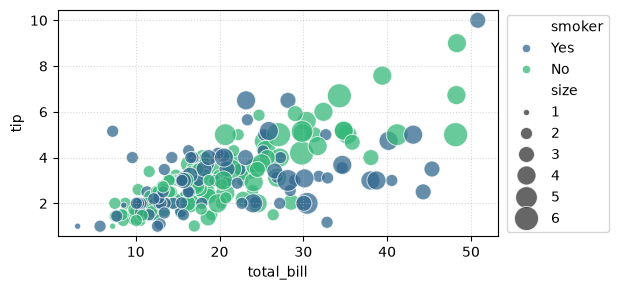

In [32]:
fig, ax = plt.subplots(figsize=(6.3, 3))

sns.scatterplot(data=tips, x="total_bill", y="tip",
                size="size",       # taille des bulles
                sizes=(20, 300),   # plage des tailles
                hue="smoker",      # couleur par catégorie
                palette="viridis", # convention du livre
                alpha=0.75, ax=ax)

ax.set_xlabel('total_bill')
ax.set_ylabel('tip')
ax.grid(True, axis='both', linestyle=':', alpha=0.5)

ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)

plt.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap2_Bulle")

plt.show()

<h3><span style="font-size: 30px">&#127924;</span> Figure : Diagramme de dispersion entre <i>total_bill</i> et <i>tip</i> du jeu de données <i>tips</i></h3>

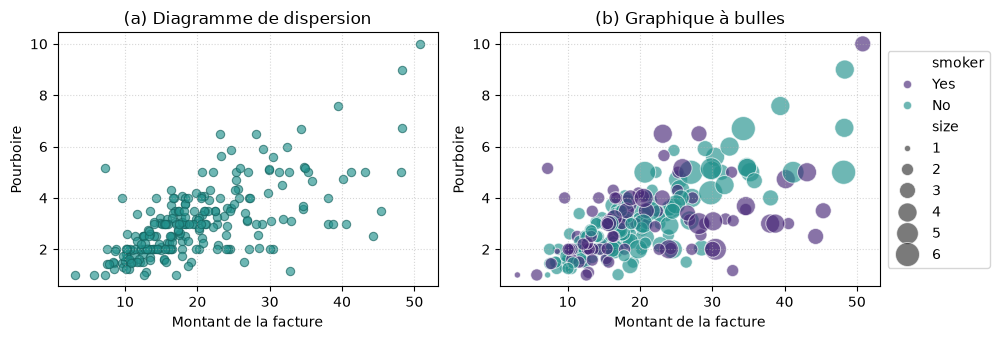

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

# (a) Diagramme de dispersion
sns.scatterplot(data=tips, x="total_bill", y="tip",
                color=SARCELLE, edgecolor=BORD[SARCELLE], linewidth=0.8,
                alpha=0.65, ax=axes[0])
axes[0].set_title('(a) Diagramme de dispersion')

# (b) Graphique à bulles
sns.scatterplot(data=tips, x="total_bill", y="tip",
                size="size", sizes=(20, 300),
                hue="smoker", palette=[VIOLET, SARCELLE],
                alpha=0.65, ax=axes[1])
axes[1].set_title('(b) Graphique à bulles')

# Mise en forme commune
for ax in axes:
    ax.set_xlabel('Montant de la facture')
    ax.set_ylabel('Pourboire')
    ax.grid(True, axis='both', linestyle=':', alpha=0.5)

plt.tight_layout()

# légende ajoutée après, elle déborde sans déformer les axes
axes[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)

save_figure(fig, "Figures/Fig-Chap2_ScatterBulle")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 2.25 : Diagramme de chaleur des corrélations (<i>tips</i>)</h3>

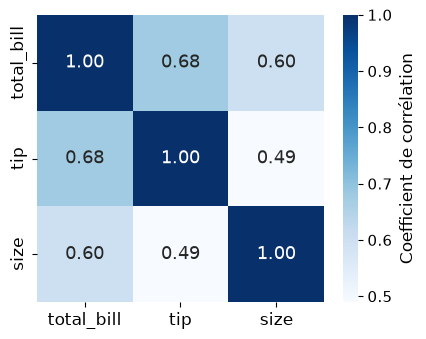

In [34]:
# Sélection des colonnes numériques
numeric_cols = tips[["total_bill", "tip", "size"]]

# Calcul de la matrice de corrélation
corr = numeric_cols.corr()

# Affichage du diagramme de chaleur (code élidé dans le livre)
fig, ax = plt.subplots(figsize=(4.5, 3.5))

sns.heatmap(corr, cmap='Blues', annot=True, fmt=".2f", square=True,
            annot_kws={'size': 13}, ax=ax,
            cbar_kws={'label': 'Coefficient de corrélation'})

ax.tick_params(axis='both', labelsize=12)

# police de la barre de couleur
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=11)
cbar.ax.set_ylabel('Coefficient de corrélation', fontsize=12)

plt.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap2_Heat")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 2.26 : Statistiques descriptives des quatre jeux du quartet d'Anscombe</h3>

In [35]:
ans = sns.load_dataset("anscombe")
statistiques = []

for nom, groupe in ans.groupby("dataset"):
    statistiques.append((
        nom,
        groupe["x"].mean(),
        groupe["y"].mean(),
        groupe["y"].var(),
        groupe["x"].corr(groupe["y"])
    ))

# --- Affichage ---
L = 66
print("=" * L)
print("Statistiques descriptives du quartet d'Anscombe")
print("=" * L)
print(f"{'Jeu':<8}"
      f"{'Moyenne x':>13}"
      f"{'Moyenne y':>13}"
      f"{'Variance y':>16}"
      f"{'Coefficient r':>16}")
print("-" * L)

for nom, moyenne_x, moyenne_y, variance_y, correlation in statistiques:
    print(f"{nom:<8}"
          f"{moyenne_x:>13.2f}"
          f"{moyenne_y:>13.2f}"
          f"{variance_y:>16.2f}"
          f"{correlation:>16.3f}")

print("=" * L)

Statistiques descriptives du quartet d'Anscombe
Jeu         Moyenne x    Moyenne y      Variance y   Coefficient r
------------------------------------------------------------------
I                9.00         7.50            4.13           0.816
II               9.00         7.50            4.13           0.816
III              9.00         7.50            4.12           0.816
IV               9.00         7.50            4.12           0.817


<h3><span style="font-size: 30px">&#127924;</span> Figure : Le quartet d'Anscombe : quatre structures, mêmes statistiques</h3>

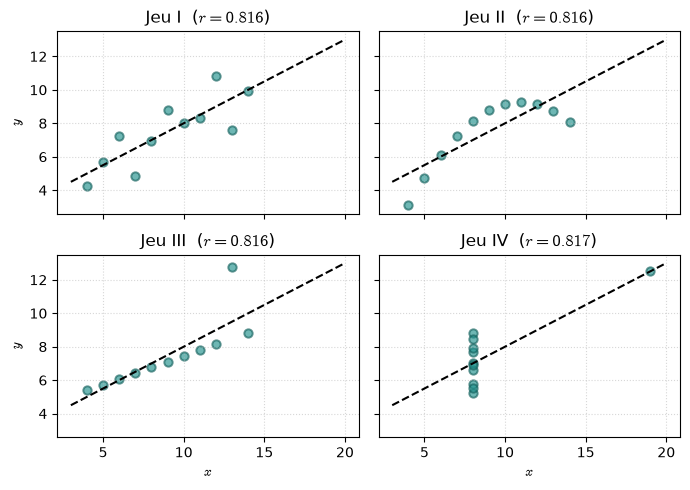

In [36]:
# Quatre nuages de points et la droite de régression commune (pointillés)
fig, axes = plt.subplots(2, 2, figsize=(7, 5), sharex=True, sharey=True)
x_line = np.linspace(3, 20, 10)

for ax, (nom, grp) in zip(axes.ravel(), ans.groupby("dataset")):
    ax.scatter(grp.x, grp.y, color=SARCELLE,
               edgecolor=BORD[SARCELLE], linewidth=1.4, alpha=0.65)
    # Droite de régression (identique pour les quatre jeux)
    pente, ordonnee = np.polyfit(grp.x, grp.y, 1)
    ax.plot(x_line, pente * x_line + ordonnee,
            color='black', linestyle='--', linewidth=1.5)
    ax.set_title(f"Jeu {nom}  ($r = {grp.x.corr(grp.y):.3f}$)")
    ax.grid(True, linestyle=':', alpha=0.5)

for ax in axes[1, :]:
    ax.set_xlabel('$x$')
for ax in axes[:, 0]:
    ax.set_ylabel('$y$')

plt.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap2_Anscombe")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 2.27 : Matrice de nuages de points des variables quantitatives (<i>tips</i>)</h3>

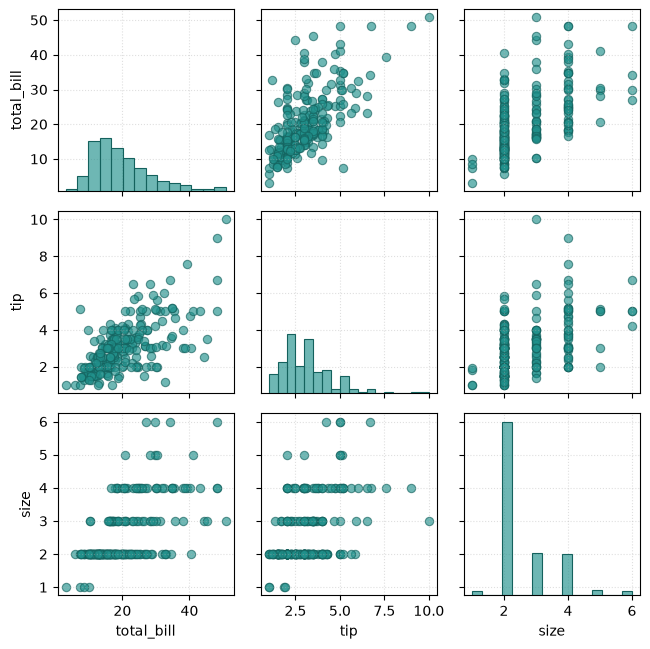

In [37]:
g = sns.pairplot(
    tips[["total_bill", "tip", "size"]],
    height=2.2,          # taille de chaque sous-graphique (pouces)
    plot_kws={
        "color": SARCELLE,
        "alpha": 0.65,
        "edgecolor": BORD[SARCELLE],
        "linewidth": 0.8
    },
    diag_kws={
        "color": SARCELLE,
        "alpha": 0.65,
        "edgecolor": BORD[SARCELLE],
        "linewidth": 0.8
    }
)

# Cadre complet sur chaque sous-graphique
for ax in g.axes.flatten():
    for spine in ax.spines.values():
        spine.set_visible(True)
    ax.grid(True, linestyle=':', alpha=0.4)

g.figure.tight_layout()

# Sauvegarder la figure
save_figure(g.figure, "Figures/Fig-Chap2_Pairplot")

plt.show()

<hr style='border-top:4px solid #1F77B4;'>